## Features

The models are trained, cross validated and compared on 3 feature sets.

**Feature Set 1**: only player statistical features

**Feature Set 2**: statistical features based on player statistic differences. Intuitively, one can argue that differences in player statistics—such as match win ratio or frame win ratio—may be sufficient for the prediction scenario that we have. We confirm this claim by investigating corrleations between these feature and actual win percentage, as shown below.

**Feature Set 3**: all available features

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns 
import numpy as np 
import os 
import pandas as pd 

In [5]:
df = pd.read_csv('match_data_300_tourns_modified.csv')

In [24]:
features_to_remove = ['player1', 'player2', 
                      'score1','score2','match_result','tournament_id']
df_ = df.drop(columns=features_to_remove) 
correlations = df_.corr()['win_percentage'].drop('win_percentage')
correlations = correlations.reindex(correlations.abs().sort_values(ascending=False).index)
print("Correlation with win percentage \n",correlations)

Correlation with win percentage 
 elo_match_win_rate          0.444988
elo_frame_win_rate          0.437116
player1_elo                 0.224803
player2_elo                -0.218702
p1_frames_won_3_years       0.201114
p1_frames_played_3_years    0.198630
p2_frames_won_3_years      -0.188409
p2_frames_played_3_years   -0.186126
p1_matches_won              0.165106
p1_matches_played           0.160169
p1_frames_won               0.158917
p1_frames_played            0.155919
p2_matches_won             -0.155563
p2_matches_played          -0.150385
p2_frames_won              -0.148245
p2_frames_played           -0.145045
p1_frames_won_1_year        0.139522
p1_frames_played_1_year     0.132124
p2_frames_won_1_year       -0.131668
p2_frames_played_1_year    -0.125887
date                       -0.002111
best_of                     0.001809
Name: win_percentage, dtype: float64


The statistics by themselves share absolute correlation coefficients of less than 0.2 with win pecentage.

In [23]:
dfm = df.copy()
dfm['p1_matches_win_ratio']=dfm['p1_matches_won']/df['p1_matches_played']
dfm['p2_matches_win_ratio']=dfm['p2_matches_won']/df['p2_matches_played']
dfm['p1_frames_win_ratio']=dfm['p1_frames_won']/df['p1_frames_played']
dfm['p2_frames_win_ratio']=dfm['p2_frames_won']/df['p2_frames_played']
dfm['p1_frames_win_ratio_1_year']=dfm['p1_frames_won_1_year']/df['p1_frames_played_1_year']
dfm['p2_frames_win_ratio_1_year']=dfm['p2_frames_won_1_year']/df['p2_frames_played_1_year']
dfm['p1_frames_win_ratio_3_years']=dfm['p1_frames_won_3_years']/df['p1_frames_played_3_years']
dfm['p2_frames_win_ratio_3_years']=dfm['p2_frames_won_3_years']/df['p2_frames_played_3_years']
dfm.fillna(0.5, inplace=True)
dfm['matches_win_ratio_diff']=dfm['p1_matches_win_ratio']-dfm['p2_matches_win_ratio']
dfm['frames_win_ratio_diff']=dfm['p1_frames_win_ratio']-dfm['p2_frames_win_ratio']
dfm['frames_win_ratio_diff_1_year']=dfm['p1_frames_win_ratio_1_year']-dfm['p2_frames_win_ratio_1_year']
dfm['frames_win_ratio_diff_3_years']=dfm['p1_frames_win_ratio_3_years']-dfm['p2_frames_win_ratio_3_years']
selected_features = ['matches_win_ratio_diff','frames_win_ratio_diff','frames_win_ratio_diff_1_year','frames_win_ratio_diff_3_years','win_percentage']
dfm_=dfm[selected_features]
correlations = dfm_.corr()['win_percentage'].drop('win_percentage')  # exclude self-correlation
correlations = correlations.reindex(correlations.abs().sort_values(ascending=False).index)
print("Correlation with win percentage \n",correlations)

Correlation with win percentage 
 matches_win_ratio_diff           0.346157
frames_win_ratio_diff            0.337987
frames_win_ratio_diff_3_years    0.333932
frames_win_ratio_diff_1_year     0.243961
Name: win_percentage, dtype: float64


The differences are more corelated with win percentage.

## Summary of training

All models except linear regression are hyperparameter tuned using Grid Search CV. Best tuned models will be used for performance comparison on final holdout set.

- **Linear Regression**
  - Feature set 1 CV average MAE : 0.2260
  - Feature set 1 CV average MAE : 0.2275
  - Feature set 1 CV average MAE : 0.2163
- **kNN**
  - Feature set 1 CV average MAE : 0.2251
  - Feature set 1 CV average MAE : 0.2364
  - Feature set 1 CV average MAE : 0.2209
- **Decision Tree**
  - Feature set 1 CV average MAE : 0.2200
  - Feature set 1 CV average MAE : 0.2275
  - Feature set 1 CV average MAE : 0.2136
- **Random Forest**
  - Feature set 1 CV average MAE : .....
  - Feature set 1 CV average MAE : .....
  - Feature set 1 CV average MAE : .....
- **XGBoost**
  - Feature set 1 CV average MAE : 0.2142
  - Feature set 1 CV average MAE : 0.2257
  - Feature set 1 CV average MAE : 0.2092





## Test & Comparison

MAE for the baseline model: 0.2476

Elo MAE: 0.2210

## Testing on holdout

In [26]:
df = pd.read_csv('match_data_300_tourns_modified.csv')


In [27]:
from sklearn.model_selection import train_test_split
df_train, df_test = train_test_split(df, 
                                        test_size = 0.2,
                                        shuffle=False)

In [36]:
#features set 1
features_to_remove = ['player1', 'player2', 'player1_elo','player2_elo','elo_match_win_rate','elo_frame_win_rate',
                      'score1','score2','match_result','win_percentage','tournament_id']
X1_train = df_train.drop(columns=features_to_remove)
y1_train = df_train['win_percentage']
X1_test = df_test.drop(columns=features_to_remove)
y1_test = df_test['win_percentage']

In [37]:
#feature set 2
dfm = df_train.copy()
dfm['p1_matches_win_ratio']=dfm['p1_matches_won']/df['p1_matches_played']
dfm['p2_matches_win_ratio']=dfm['p2_matches_won']/df['p2_matches_played']
dfm['p1_frames_win_ratio']=dfm['p1_frames_won']/df['p1_frames_played']
dfm['p2_frames_win_ratio']=dfm['p2_frames_won']/df['p2_frames_played']
dfm['p1_frames_win_ratio_1_year']=dfm['p1_frames_won_1_year']/df['p1_frames_played_1_year']
dfm['p2_frames_win_ratio_1_year']=dfm['p2_frames_won_1_year']/df['p2_frames_played_1_year']
dfm['p1_frames_win_ratio_3_years']=dfm['p1_frames_won_3_years']/df['p1_frames_played_3_years']
dfm['p2_frames_win_ratio_3_years']=dfm['p2_frames_won_3_years']/df['p2_frames_played_3_years']
dfm.fillna(0.5, inplace=True)
dfm['matches_win_ratio_diff']=dfm['p1_matches_win_ratio']-dfm['p2_matches_win_ratio']
dfm['frames_win_ratio_diff']=dfm['p1_frames_win_ratio']-dfm['p2_frames_win_ratio']
dfm['frames_win_ratio_diff_1_year']=dfm['p1_frames_win_ratio_1_year']-dfm['p2_frames_win_ratio_1_year']
dfm['frames_win_ratio_diff_3_years']=dfm['p1_frames_win_ratio_3_years']-dfm['p2_frames_win_ratio_3_years']
selected_features = ['matches_win_ratio_diff','frames_win_ratio_diff','frames_win_ratio_diff_1_year','frames_win_ratio_diff_3_years']
X2_train = dfm[selected_features]
y2_train = dfm['win_percentage']
dfm = df_test.copy()
dfm['p1_matches_win_ratio']=dfm['p1_matches_won']/df['p1_matches_played']
dfm['p2_matches_win_ratio']=dfm['p2_matches_won']/df['p2_matches_played']
dfm['p1_frames_win_ratio']=dfm['p1_frames_won']/df['p1_frames_played']
dfm['p2_frames_win_ratio']=dfm['p2_frames_won']/df['p2_frames_played']
dfm['p1_frames_win_ratio_1_year']=dfm['p1_frames_won_1_year']/df['p1_frames_played_1_year']
dfm['p2_frames_win_ratio_1_year']=dfm['p2_frames_won_1_year']/df['p2_frames_played_1_year']
dfm['p1_frames_win_ratio_3_years']=dfm['p1_frames_won_3_years']/df['p1_frames_played_3_years']
dfm['p2_frames_win_ratio_3_years']=dfm['p2_frames_won_3_years']/df['p2_frames_played_3_years']
dfm.fillna(0.5, inplace=True)
dfm['matches_win_ratio_diff']=dfm['p1_matches_win_ratio']-dfm['p2_matches_win_ratio']
dfm['frames_win_ratio_diff']=dfm['p1_frames_win_ratio']-dfm['p2_frames_win_ratio']
dfm['frames_win_ratio_diff_1_year']=dfm['p1_frames_win_ratio_1_year']-dfm['p2_frames_win_ratio_1_year']
dfm['frames_win_ratio_diff_3_years']=dfm['p1_frames_win_ratio_3_years']-dfm['p2_frames_win_ratio_3_years']
selected_features = ['matches_win_ratio_diff','frames_win_ratio_diff','frames_win_ratio_diff_1_year','frames_win_ratio_diff_3_years']
X2_test = dfm[selected_features]
y2_test = dfm['win_percentage']

In [38]:
#feature set 3
features_to_remove = ['player1', 'player2', 
                      'score1','score2','match_result','win_percentage','tournament_id']
X3_train = df_train.drop(columns=features_to_remove) 
y3_train = df_train['win_percentage']
X3_test = df_test.drop(columns=features_to_remove) 
y3_test = df_test['win_percentage']

### Linear Regression

In [44]:
from sklearn.metrics import mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
    ])
pipeline.fit(X1_train, y1_train)


y_pred = pipeline.predict(X1_test)

mae = mean_absolute_error(y1_test, y_pred)
print(f"Test MAE with feature set 1: {mae} \n")

Test MAE with feature set 1: 0.2325099990771555 



In [46]:


pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
    ])
pipeline.fit(X2_train, y2_train)

y_pred = pipeline.predict(X2_test)

mae = mean_absolute_error(y2_test, y_pred)
print(f"Test MAE with feature set 1: {mae} \n")

Test MAE with feature set 1: 0.226569146129604 



In [47]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
    ])
pipeline.fit(X3_train, y3_train)

y_pred = pipeline.predict(X3_test)

mae = mean_absolute_error(y3_test, y_pred)
print(f"Test MAE with feature set 1: {mae} \n")

Test MAE with feature set 1: 0.22028087437625532 



### kNN

Best parameters: {'knn__n_neighbors': 9} for feature set 1

Best parameters: {'knn__n_neighbors': 9} for feature set 2

Best parameters: {'knn__n_neighbors': 9} for feature set 3

In [52]:
from sklearn.neighbors import KNeighborsRegressor

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsRegressor(n_neighbors=9))
])


pipeline.fit(X1_train, y1_train)

y_pred = pipeline.predict(X1_test)

mae = mean_absolute_error(y1_test, y_pred)
print(f"Test MAE with feature set 1: {mae} \n")

Test MAE with feature set 1: 0.22917869120504 



In [53]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsRegressor(n_neighbors=9))
])

pipeline.fit(X2_train, y2_train)

y_pred = pipeline.predict(X2_test)

mae = mean_absolute_error(y2_test, y_pred)
print(f"Test MAE with feature set 2: {mae} \n")

Test MAE with feature set 2: 0.2359341398396673 



In [54]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsRegressor(n_neighbors=9))
])

pipeline.fit(X3_train, y3_train)

y_pred = pipeline.predict(X3_test)

mae = mean_absolute_error(y3_test, y_pred)
print(f"Test MAE with feature set 3: {mae} \n")


Test MAE with feature set 3: 0.22189468452429367 



### Decision Tree

Best parameters: {'ccp_alpha': 0.0, 'max_depth': 5, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2} for feature set 1

Best parameters: {'ccp_alpha': 0.0, 'max_depth': 5, 'max_features': None, 'min_samples_leaf': 4, 'min_samples_split': 10} for feature set 2

Best parameters: {'ccp_alpha': 0.0, 'max_depth': 5, 'max_features': None, 'min_samples_leaf': 2, 'min_samples_split': 2} for feature set 3

In [58]:
from sklearn.tree import DecisionTreeRegressor

best_params = {
    'ccp_alpha': 0.0,
    'max_depth': 5,
    'max_features': None,
    'min_samples_leaf': 1,
    'min_samples_split': 2
}

model = DecisionTreeRegressor(
    random_state=20,
    **best_params
)

model.fit(X1_train, y1_train)

y_pred = model.predict(X1_test)

mae = mean_absolute_error(y1_test, y_pred)
print(f"Test MAE with feature set 1: {mae} \n")

Test MAE with feature set 1: 0.22327411675227668 



In [68]:
best_params = {
    'ccp_alpha': 0.0,
    'max_depth': 5,
    'max_features': None,
    'min_samples_leaf': 4,
    'min_samples_split': 10
}

model = DecisionTreeRegressor(
    random_state=20,
    **best_params
)

model.fit(X2_train, y2_train)

y_pred = model.predict(X2_test)

mae = mean_absolute_error(y2_test, y_pred)
print(f"Test MAE with feature set 3: {mae} \n")

Test MAE with feature set 3: 0.22682148679609992 



In [60]:
best_params = {
    'ccp_alpha': 0.0,
    'max_depth': 5,
    'max_features': None,
    'min_samples_leaf': 2,
    'min_samples_split': 2
}

model = DecisionTreeRegressor(
    random_state=20,
    **best_params
)

model.fit(X3_train, y3_train)

y_pred = model.predict(X3_test)

mae = mean_absolute_error(y3_test, y_pred)
print(f"Test MAE with feature set 3: {mae} \n")

Test MAE with feature set 3: 0.2135608634078601 



### XG Boost

Best parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8} for feature set 1

Best parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8} for feature set 2

Best parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8} for features et 3

In [62]:
from xgboost import XGBRegressor

params = {
    'colsample_bytree': 0.8,
    'learning_rate': 0.1,
    'max_depth': 3,
    'n_estimators': 200,
    'subsample': 0.8
}

model = XGBRegressor(**params)
model.fit(X1_train, y1_train)

y_pred = model.predict(X1_test)

mae = mean_absolute_error(y1_test, y_pred)
print(f"Test MAE with feature set 1: {mae} \n")

Test MAE with feature set 1: 0.21924989216310145 



In [67]:
params = {
    'colsample_bytree': 0.8,
    'learning_rate': 0.1,
    'max_depth': 3,
    'n_estimators': 100,
    'subsample': 0.8
}

model = XGBRegressor(**params)
model.fit(X2_train, y2_train)

y_pred = model.predict(X2_test)

mae = mean_absolute_error(y2_test, y_pred)
print(f"Test MAE with feature set 2: {mae} \n")

Test MAE with feature set 2: 0.22507258462701607 



In [66]:
params = {
    'colsample_bytree': 1.0,
    'learning_rate': 0.1,
    'max_depth': 3,
    'n_estimators': 100,
    'subsample': 0.8
}

model = XGBRegressor(**params)
model.fit(X3_train, y3_train)

y_pred = model.predict(X3_test)

mae = mean_absolute_error(y3_test, y_pred)
print(f"Test MAE with feature set 3: {mae} \n")

Test MAE with feature set 3: 0.2104541706298341 



- **Linear Regression**
  - Test MAE using feature set 1: 0.2325
  - Test MAE using feature set 2: 0.2266
  - Test MAE using feature set 3: 0.2203
- **kNN**
  - Test MAE using feature set 1: 0.2292
  - Test MAE using feature set 2: 0.2359
  - Test MAE using feature set 3: 0.2219
- **Decision Tree**
  - Test MAE using feature set 1: 0.2233
  - Test MAE using feature set 2: 0.2268
  - Test MAE using feature set 3: 0.2136
- **Random Forest**
  - Test MAE using feature set 1: 
  - Test MAE using feature set 2: 
  - Test MAE using feature set 3: 
- **XGBoost**
  - Test MAE using feature set 1: 0.2192
  - Test MAE using feature set 2: 0.2251
  - Test MAE using feature set 3: 0.2105 
- **Baseline model** MAE : 0.2476
- **Elo** MAE: 0.2210  

/var/folders/77/y6gtmx8d687_4xqlf5hz3z7r0000gn/T/ipykernel_74842/2732448609.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(sorted_values), y=list(sorted_labels), palette='Blues_d')


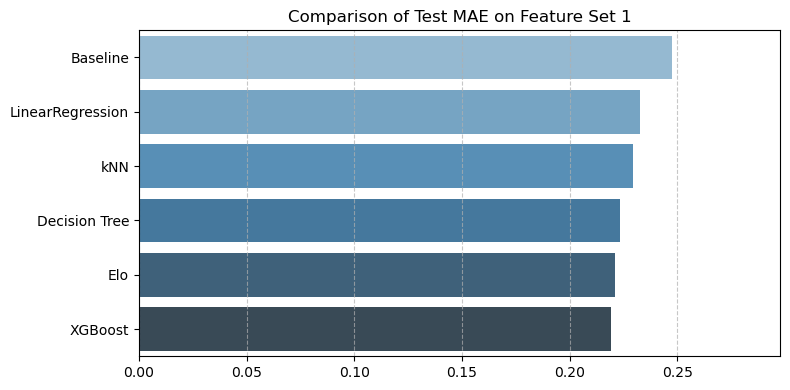

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

mae_values = [0.2476,0.2210,0.2325, 0.2292, 0.2233, 0.2192]
models = ['Baseline','Elo','LinearRegression', 'kNN', 'Decision Tree', 'XGBoost']


sorted_pairs = sorted(zip(mae_values, models), reverse=True)
sorted_values, sorted_labels = zip(*sorted_pairs)

plt.figure(figsize=(8, 4))
sns.barplot(x=list(sorted_values), y=list(sorted_labels), palette='Blues_d')

plt.title('Comparison of Test MAE on Feature Set 1')
plt.xlim(0, max(mae_values) + 0.05)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

/var/folders/77/y6gtmx8d687_4xqlf5hz3z7r0000gn/T/ipykernel_74842/4208424011.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(sorted_values), y=list(sorted_labels), palette='Blues_d')


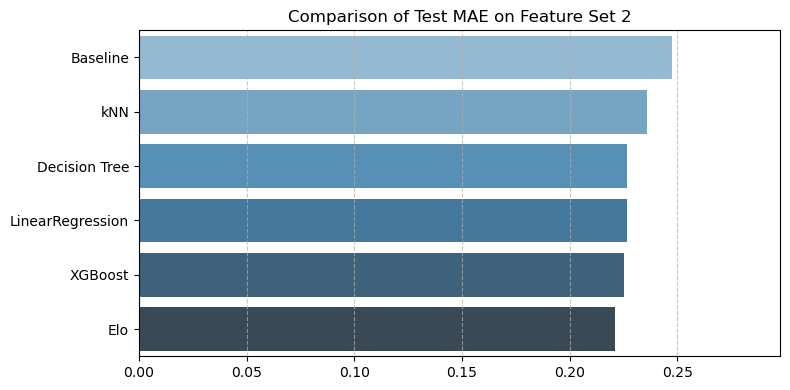

In [ ]:
mae_values = [0.2476,0.2210,0.2266, 0.2359, 0.2268, 0.2251]
models = ['Baseline','Elo','LinearRegression', 'kNN', 'Decision Tree', 'XGBoost']

sorted_pairs = sorted(zip(mae_values, models), reverse=True)
sorted_values, sorted_labels = zip(*sorted_pairs)

plt.figure(figsize=(8, 4))
sns.barplot(x=list(sorted_values), y=list(sorted_labels), palette='Blues_d')

plt.title('Comparison of Test MAE on Feature Set 2')
plt.xlim(0, max(mae_values) + 0.05)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

/var/folders/77/y6gtmx8d687_4xqlf5hz3z7r0000gn/T/ipykernel_74842/1640214005.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(sorted_values), y=list(sorted_labels), palette='Blues_d')


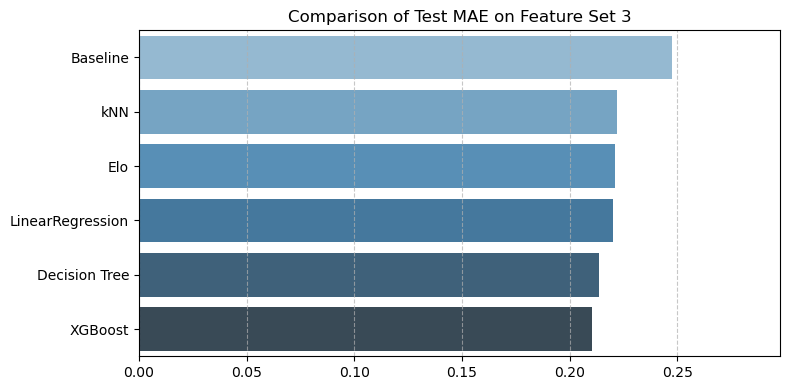

In [74]:
mae_values = [0.2476,0.2210,0.2203, 0.2219, 0.2136, 0.2105]
models = ['Baseline','Elo','LinearRegression', 'kNN', 'Decision Tree', 'XGBoost']

sorted_pairs = sorted(zip(mae_values, models), reverse=True)
sorted_values, sorted_labels = zip(*sorted_pairs)

plt.figure(figsize=(8, 4))
sns.barplot(x=list(sorted_values), y=list(sorted_labels), palette='Blues_d')

plt.title('Comparison of Test MAE on Feature Set 3')
plt.xlim(0, max(mae_values) + 0.05)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()